## **Overview**

This project revisits a scientific-programming exercise on **three-body bond-angle distributions** in model atomic systems. I use it to explore both structural information contained in bond-angle distributions and the numerical choices involved in neighbour identification. The original coursework implementation and accompanying write-up have been reorganised and annotated here as part of my later revision.

To keep it concise this work mainly contains the code. Discussions are made in the explanary text.



## **Objective**
The model is deliberately simple, providing an intuitive setting in which the relationship between atomic arrangement and local three-body geometry can be examined directly. By changing the degree and type of structural order while keeping the underlying analysis consistent, the same framework can be used to observe how bond-angle distributions respond to increasingly different atomic environments. More realistic physical effects can subsequently be incorporated on top of this basic framework.

Specifically, the project considers four related structural scenarios:

1. *General periodic configuration*:
How can local three-body geometry be defined and computed consistently in a finite simulation cell representing an infinite periodic system?

2. *Ordered atomic structure*:
How is structural order reflected in the bond-angle distribution?

3. *Positional disorder / perturbed structure*:
How does the bond-angle distribution change when atoms are displaced from their ideal lattice positions?

4. *Uncorrelated reference system*:
What does the bond-angle distribution look like in the absence of underlying structural order? We discuss the ideal gas configuration for example.

From a computational perspective, the main focus is the **neighbour-identification step**, which forms the numerical bottleneck of the bond-angle calculation. **Four** approaches are investigated: ***brute-force search, a vectorised implementation, KD-tree search, and a cell-linked-list method***. Their results are compared not only for computational efficiency and scalability, but also for numerical consistency, so that improvements in performance do not come at the expense of the accuracy of the calculated bond-angle distributions.




In [1]:
import sys
print(sys.executable)

d:\00_2026_phd_application\Computational_Practice_MSc\.venv\Scripts\python.exe


## **Building the simulation system**
The first step is to define the simulation cell and then populate it with particles.
In this project, I use two different approaches to construct the atomic system. The first approach is a simple implementation written directly in NumPy. A general periodic cell is defined using three lattice vectors, and particles can then be placed inside the cell either randomly or in a regular ordered array(Ojective1&2). This provides a simple framework for comparing disordered and ordered configurations while keeping the underlying analysis unchanged.
Randomly populated cells are useful for constructing an uncorrelated reference configuration, while regularly ordered arrays provide a simple model for examining how structural order appears in the bond-angle distribution.
The second approach uses ASE. For standard physical crystal structures, ASE provides a more convenient way to generate predefined lattices and supercells, such as FCC, BCC and diamond structures. This is useful when moving from the simple geometric models above to more realistic atomic structures.

In [2]:
import numpy as np


def make_cell(a, b, c):
    """
    Construct a 3D periodic simulation cell from three linearly independent cell vectors(lattice vector).
    Lattice vectors defining the size and shape of the simulation cell.
    Cartesian components are given in angstroms (Å).
    Returns cell : ndarray, shape (3, 3)
    Cell vectors stored as rows(row vectors).
    """
    cell = np.array([a, b, c], dtype=float)

    if cell.shape != (3, 3):
        raise ValueError("A 3D cell must contain three 3D vectors.")

    if np.isclose(np.linalg.det(cell), 0.0):
        raise ValueError("Cell vectors must be linearly independent.")

    return cell

### **Periodic boundary conditions**

Periodic boundary conditions are important for the following parts of this project.

At this stage, the simulation cell has already been defined. The next step is to populate the cell with particles. When generating particle positions, we do not want two particles to be placed too close to each other or to overlap. Therefore, when checking the separation between a newly generated particle and the particles already in the cell, periodic boundary conditions need to be considered. This is because simply calculating the Euclidean distance between two Cartesian positions is not always sufficient in a periodic system. Two particles may appear to be far apart inside the primary simulation cell, while their nearest periodic images are actually very close to each other.

The same issue also appears later during neighbour searching. A particle close to one boundary of the simulation cell may be a neighbour of another particle close to the opposite boundary. Therefore, the minimum-image displacement should be used before calculating the interparticle distance.

The The `pbc()` function below is therefore used both during particle generation and during neighbour identification.

In [3]:
def pbc(displacement, cell):
    """
    This function applies periodic boundary conditions to a Cartesian displacement vector
    and finds the shortest equivalent displacement under periodicity, where

    displacement : array_like, shape (3,) Cartesian displacement vector between two atoms.
    cell : ndarray, shape (3, 3) Cell vectors stored as rows.

    Returns
    -------
    ndarray, shape (3,)
        Minimum-image displacement vector in Cartesian coordinates.
    """
    fractional = displacement @ np.linalg.inv(cell)
    fractional -= np.round(fractional)

    return fractional @ cell

Too keep things in general we populate the box with particles at random position(objective 1). To avoid unrealistically close particle pairs, a minimum allowed interparticle separation is introduced during random particle generation.

In [4]:
def generate_random_positions(n_particles, cell, min_distance, seed=None):

    """ The function is used to generate random particles, where
        
        n_particles: number of particles
        cell: simulation cell
        min_distance:the minimum distance between two particles to avoild unphysically overlap or close particle pairs 
    
    """

    rng = np.random.default_rng(seed)
    positions = []

    while len(positions) < n_particles:

        fractional_position = rng.random(3)
        candidate = fractional_position @ cell

        valid = True

        for position in positions:

            displacement = candidate - position
            displacement = pbc(displacement, cell)

            distance = np.linalg.norm(displacement)

            if distance < min_distance:
                valid = False
                break

        if valid:
            positions.append(candidate)

    return np.array(positions)

In [5]:
def generate_ordered_positions(cell, n_a, n_b, n_c):
    """
    Generate regularly spaced particle positions inside a periodic cell.

    The ordered grid is first constructed in fractional coordinates
    and then transformed into Cartesian coordinates.
    """
    positions = []

    for i in range(n_a):
        for j in range(n_b):
            for k in range(n_c):

                fractional = np.array([
                    i / n_a,
                    j / n_b,
                    k / n_c
                ])

                position = fractional @ cell
                positions.append(position)

    return np.array(positions)

Alternatively, Generating physical crystal structures with ASE
The ordered array above is a simple geometric construction. For standard crystal structures, it is more convenient to use established tools such as ASE, which can generate common lattices and supercells directly.

In [6]:
from ase.build import bulk
from ase.visualize import view

#primitive cells
# FCC aluminium
al_fcc = bulk("Al", "fcc", a=4.05)

# BCC iron
fe_bcc = bulk("Fe", "bcc", a=2.87)

# Diamond silicon
si_diamond = bulk("Si", "diamond", a=5.43)

In [7]:
#Al as example
al_supercell = al_fcc.repeat((3, 3, 3))
print(al_supercell.cell)
print(al_supercell.positions)
view(al_supercell)

Cell([[0.0, 6.074999999999999, 6.074999999999999], [6.074999999999999, 0.0, 6.074999999999999], [6.074999999999999, 6.074999999999999, 0.0]])
[[0.    0.    0.   ]
 [2.025 2.025 0.   ]
 [4.05  4.05  0.   ]
 [2.025 0.    2.025]
 [4.05  2.025 2.025]
 [6.075 4.05  2.025]
 [4.05  0.    4.05 ]
 [6.075 2.025 4.05 ]
 [8.1   4.05  4.05 ]
 [0.    2.025 2.025]
 [2.025 4.05  2.025]
 [4.05  6.075 2.025]
 [2.025 2.025 4.05 ]
 [4.05  4.05  4.05 ]
 [6.075 6.075 4.05 ]
 [4.05  2.025 6.075]
 [6.075 4.05  6.075]
 [8.1   6.075 6.075]
 [0.    4.05  4.05 ]
 [2.025 6.075 4.05 ]
 [4.05  8.1   4.05 ]
 [2.025 4.05  6.075]
 [4.05  6.075 6.075]
 [6.075 8.1   6.075]
 [4.05  4.05  8.1  ]
 [6.075 6.075 8.1  ]
 [8.1   8.1   8.1  ]]


<Popen: returncode: None args: ['d:\\00_2026_phd_application\\Computational_...>

## **Neighbor List Search**
For the following neighbour-search tests, a simple cubic simulation cell is used so that the geometry remains easy to inspect while the search algorithms are compared under the same conditions.

#### **The example of cubic cell**

In [8]:
a = np.array([10.0, 0.0, 0.0])
b = np.array([0.0, 10.0, 0.0])
c = np.array([0.0, 0.0, 10.0])

cell = make_cell(a, b, c)

To compare the effect of structural order, the ordered and random systems are constructed using the same simulation cell and the same number of particles. This keeps the number density fixed, so differences in the resulting bond-angle distributions arise primarily from the particle arrangement. The following shows two examples with simulation box length of $10\ \text{Å}$ and 27 particles in the box. The points shown in the diagram therefore indicate particle positions rather than their physical sizes.


In [9]:
#System Setup Cell
L = 10.0 #box length
N = 27   #number of particles in one simulation cell

#### **Periodic cubic cell with random packing**

In [10]:
random_positions = generate_random_positions(
    n_particles=27,
    cell=cell,
    min_distance=0.8,
    seed=42
)


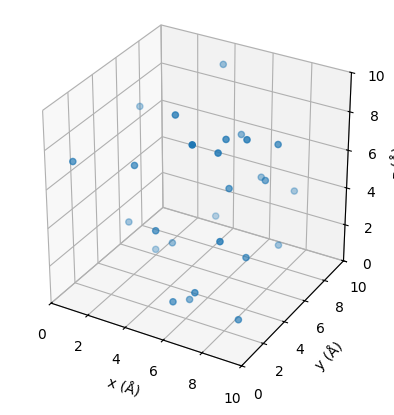

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    random_positions[:, 0],
    random_positions[:, 1],
    random_positions[:, 2]
)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_box_aspect((1, 1, 1))

plt.show()

#### **Periodic cubic cell with ordered packing**

In [12]:
ordered_positions = generate_ordered_positions(
    cell=cell,
    n_a=3,
    n_b=3,
    n_c=3
)

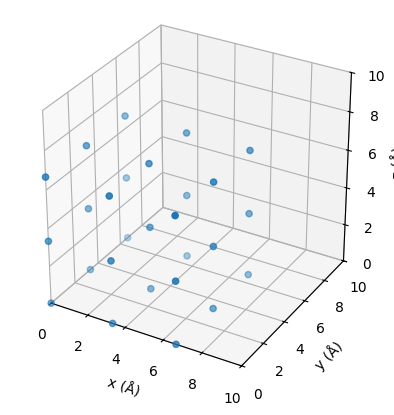

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2]
)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

ax.set_box_aspect((1, 1, 1))

plt.show()

### **The choice of cutoff distance**
After constructing the simulation system, the next step is to identify the neighbouring particles around a selected central particle.
A cutoff distance is used to define the local environment. Periodic boundary conditions are applied to the displacement vectors before calculating distances, so that neighbours across the simulation-cell boundaries are also identified correctly.

The **box length** and **cutoff distance** used here are chosen only for demonstration. They are not intended to represent a specific physical system. In practical applications, these parameters should be selected according to the particle density, characteristic interatomic distances, and the structural features of interest.

In [14]:
center_idx = 0
cutoff = 4.0

For the ordered example used here, the $3\times3\times3$ particle array is distributed uniformly inside a cubic simulation cell of length $10\ \text{Å}$. The characteristic nearest-neighbour spacing is therefore approximately
$$
\frac{10}{3} \approx 3.33\,\text{Å}.
$$

The neighbour cutoff should be chosen with this spacing in mind. If the cutoff is smaller than about $3.33\ \text{Å}$, the first nearest-neighbour shell may not be identified. A cutoff slightly larger than this value, for example $3.4$–$3.6\ \text{Å}$, mainly captures the nearest neighbours. In the simple demonstration below, a cutoff of $4.0\ \text{Å}$ is used to provide some tolerance while still focusing on the first local coordination shell.
This cutoff is chosen only for the present toy model. In a realistic atomic system, the cutoff would normally be selected according to the characteristic interatomic distances and the coordination structure of the material being studied.

In [15]:
from neighbor_search.brute_force import find_neighbors_brute_force

neighbors_bf_ordered = find_neighbors_brute_force(

    positions=ordered_positions,
    center_idx=center_idx,
    cutoff=cutoff,
    cell=cell
)

In [16]:
print(neighbors_bf_ordered)

[(1, array([0.        , 0.        , 3.33333333])), (2, array([ 0.        ,  0.        , -3.33333333])), (3, array([0.        , 3.33333333, 0.        ])), (6, array([ 0.        , -3.33333333,  0.        ])), (9, array([3.33333333, 0.        , 0.        ])), (18, array([-3.33333333,  0.        ,  0.        ]))]


Because periodic boundary conditions are applied, neighbours across opposite boundaries of the simulation cell are included in the same way as neighbours within the **primary cell**. Some neighbours appear visually distant from the central particle when plotted using their coordinates in the primary simulation cell. Under periodic boundary conditions, however, particles near the opposite boundary correspond to nearby periodic images and can therefore fall within the cutoff distance.

### **Example: The nerighbor list of cubic ordered system**

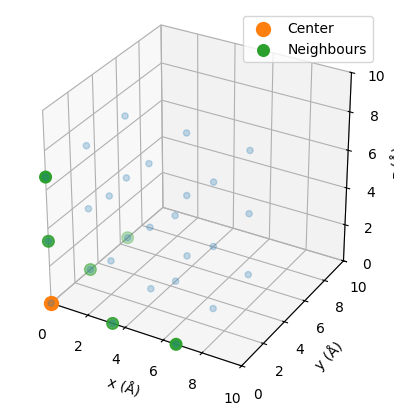

In [17]:
# Visualization:primiary cell representation
center = ordered_positions[center_idx]

neighbor_indices = [idx for idx, _ in neighbors_bf_ordered]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# all particles
ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2],
    alpha=0.25
)

# center particle
ax.scatter(
    center[0],
    center[1],
    center[2],
    s=100,
    label="Center"
)

# neighbour particles
neighbor_positions = ordered_positions[neighbor_indices]

ax.scatter(
    neighbor_positions[:, 0],
    neighbor_positions[:, 1],
    neighbor_positions[:, 2],
    s=70,
    label="Neighbours"
)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect((1, 1, 1))

ax.legend()

plt.show()

The image above shows the **central particle**(indicated in orange) and the **neighbours**(indicated in green) identified within the cutoff distance under **brute force neighbor search** , plotted using their original coordinates in the primary simulation cell. Some neighbours appear visually far from the central particle because they lie close to the opposite boundary of the cell. Under periodic boundary conditions, these particles correspond to nearby periodic images and are therefore correctly identified as neighbours.

In [18]:
neighbor_image_positions = np.array([
    center + displacement
    for _, displacement in neighbors_bf_ordered
])

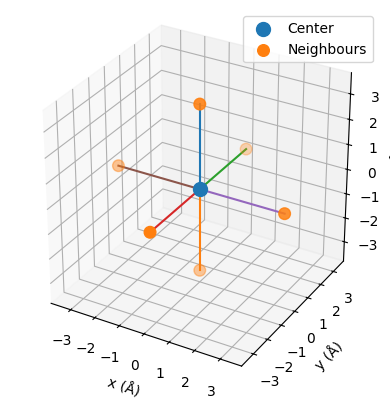

In [19]:
#Visualization: minimum-image representation
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# center
ax.scatter(
    center[0],
    center[1],
    center[2],
    s=100,
    label="Center"
)

# nearest periodic images of neighbours
ax.scatter(
    neighbor_image_positions[:, 0],
    neighbor_image_positions[:, 1],
    neighbor_image_positions[:, 2],
    s=70,
    label="Neighbours"
)

# optional: connect center to neighbours
for position in neighbor_image_positions:
    ax.plot(
        [center[0], position[0]],
        [center[1], position[1]],
        [center[2], position[2]]
    )

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.show()

The second image shows the same local environment using the minimum-image representation. Each neighbour is repositioned according to its PBC-corrected displacement from the central particle. In this representation, the neighbours form the local coordination environment around the centre more directly, and the periodic neighbours that appeared distant in the primary cell are now shown at their nearest equivalent positions.
**This minimum-image representation is also the one used in the subsequent bond-angle calculation**, because both the neighbour distances and the relative directions between neighbouring particles must be defined using the PBC-corrected displacement vectors.

## **Three-body bond-angle distribution**


After identifying the neighbours around a central particle, the next step is to construct three-body configurations and calculate the corresponding bond angles. For a central particle \(j\), any two neighbours \(i\) and \(k\) form a three-body configuratio $i-j-k$, where \(j\) is the central particle.

The bond angle is defined from the two displacement vectors from the central particle to the two neighbours,

$$
\mathbf{r}_{ji}
\quad \text{and} \quad
\mathbf{r}_{jk}.
$$

Using the dot product,

$$
\mathbf{r}_{ji}\cdot\mathbf{r}_{jk}
=
|\mathbf{r}_{ji}|
|\mathbf{r}_{jk}|
\cos\theta_{ijk},
$$

and therefore

$$
\cos\theta_{ijk}
=
\frac{
\mathbf{r}_{ji}\cdot\mathbf{r}_{jk}
}{
|\mathbf{r}_{ji}|
|\mathbf{r}_{jk}|
}.
$$

The bond angle can then be obtained from

$$
\theta_{ijk}
=
\cos^{-1}
\left(
\frac{
\mathbf{r}_{ji}\cdot\mathbf{r}_{jk}
}{
|\mathbf{r}_{ji}|
|\mathbf{r}_{jk}|
}
\right).
$$

In the current implementation, the neighbour list `neighbors_bf_ordered` already contains the PBC-corrected displacement vectors. Therefore, the bond-angle calculation can use these displacement vectors directly without applying the periodic boundary conditions again.

To make the calculation easier to inspect, I first use the ordered example introduced above. Its local geometry is simple and familiar, so it provides a useful reference for checking that the neighbour vectors and calculated bond angles are consistent with the expected structure.
The calculation is first demonstrated for a single central particle. Once the local geometry has been verified, the same procedure is applied to every particle in the simulation cell. The bond angles collected from all central particles are then combined into a histogram to obtain the bond-angle distribution (BAD) of the whole system.

For the ordered cubic example, the first-shell neighbour geometry provides a simple expectation for the calculated angles, with perpendicular neighbour directions giving \(90^\circ\) and opposite directions giving \(180^\circ\).


### **Eaxample 1 : Cubic ordered systems**

#### **Manual check of the ordered example : single center sanity check**

Before evualating the bond angels numerically,we can first inspect the geometry of the ordered example and work out the expected result directly. For the central particle considered above, there are six nearest neighbours, corresponding to the six displacement directions $+\hat{x},\;-\hat{x},\;+\hat{y},\;-\hat{y},\;+\hat{z},\;-\hat{z}.$

A three-body bond angle is formed by selecting any two neighbours around the same central particle. Since the order of the two neighbours does not create a new angle, the number of unique neighbour pairs is

$$
\binom{6}{2}
=
\frac{6\times5}{2}
=
15.
$$


Among these 15 neighbour pairs, three pairs correspond to opposite directions,$(+x,-x),(+y,-y),(+z,-z)$ and therefore give bond angles of $ 180^\circ.$ The remaining $ 15-3=12 $ pairs are combinations of mutually perpendicular directions, such as $(+x,+y),(+x,-y),(+x,+z)$ and therefore give bond angles of $90^\circ.$

The expected local-angle set is therefore

$$
12\times90^\circ
\quad+\quad
3\times180^\circ,
$$

which agrees with the numerical result as is showed as below.

> **Note.** This simple example shows how the geometric and mathematical description is translated directly into the implementation. The local geometry tells us that six neighbours produce 15 unique three-body combinations and predicts the expected bond angles. The code performs the same procedure systematically by selecting each unique pair of PBC-corrected neighbour displacement vectors and evaluating the angle from their dot product. The agreement between the two provides a simple check of the implementation

#### **Three-body Bond angle distribution(BAD) for a single centered atom at position [0,0,0]**

The function below `calculate_bond_angles` calculates all unique three-body bond angles around a chosen central particle using the neighbour displacement vectors.

For the ordered cubic example, the calculated angles are then shown as a **frequency plot**, where the height of each bar gives the number of angles falling within that angular range.

> **Note.** This first frequency plot describes the local bond-angle distribution around a **single central particle only**. It is used as a sanity check of the angle calculation before extending the same procedure to all particles in the system.

In [20]:
from itertools import combinations


def calculate_bond_angles(neighbors):
    """
    Calculate all three-body bond angles around one central particle.

    Parameters
    ----------
    neighbors : list
        List of (neighbor_idx, displacement) tuples.

    Returns
    -------
    angles : ndarray
        Bond angles in degrees.
    """

    angles = []

    for (_, displacement_1), (_, displacement_2) in combinations(neighbors, 2):

        cos_theta = np.dot(displacement_1, displacement_2) / (
            np.linalg.norm(displacement_1)
            * np.linalg.norm(displacement_2)
        )

        # Avoid numerical errors slightly outside [-1, 1]
        cos_theta = np.clip(cos_theta, -1.0, 1.0)

        theta = np.degrees(np.arccos(cos_theta))

        angles.append(theta)

    return np.array(angles)

In [ ]:
#The ordered system with simulation box length of 10 A, 27 particles and a cutoff of 4.0 A as example
angles_bf_ordered = calculate_bond_angles(neighbors_bf_ordered) #bond angles of center atoms with idex 0

print(angles_bf_ordered)
print(f"Number of neighbours: {len(neighbors_bf_ordered)}")
print(f"Number of bond angles: {len(angles_bf_ordered)}")
print(np.round(angles_bf_ordered, 2))

[180.  90.  90.  90.  90.  90.  90.  90.  90. 180.  90.  90.  90.  90.
 180.]
Number of neighbours: 6
Number of bond angles: 15
[180.  90.  90.  90.  90.  90.  90.  90.  90. 180.  90.  90.  90.  90.
 180.]


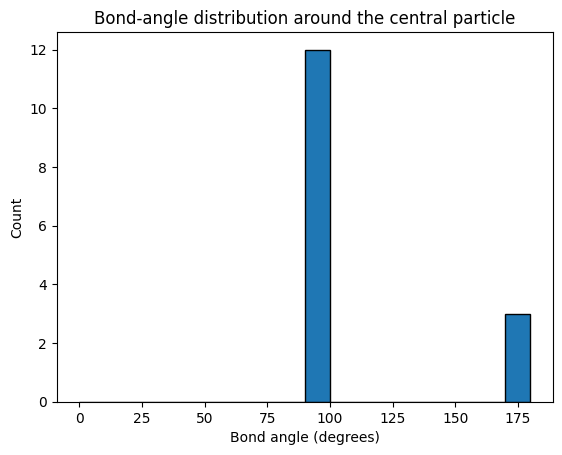

In [23]:
plt.hist(
    angles_bf_ordered,
    bins=np.arange(0, 190, 10),
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Count")
plt.title("Bond-angle distribution around the central particle")

plt.show()

#### **Bond-angle distribution over all particles in the simulation cell**

The calculation above considers the local geometry around a single central particle. To obtain the bond-angle distribution of the whole system, the same procedure is repeated for every particle in the simulation cell.

For each central particle:

1. its neighbours are identified using the same cutoff distance and periodic boundary conditions;
2. all unique pairs of neighbouring displacement vectors are constructed;
3. the corresponding bond angles are calculated.

The bond angles obtained from all central particles are then collected into a single dataset. A histogram of these angles gives the bond-angle distribution (BAD) of the system.

For the ordered example, all particles experience the same local periodic environment. We therefore expect the system-level distribution to retain the characteristic peaks of the local geometry, while containing many more angle samples than the single-particle example.

After establishing the BAD for the ordered structure, the same analysis can be applied to a periodically bounded system with randomly packed particles. Comparing the two distributions provides a simple way to examine how structural order is reflected in the local three-body geometry.

In [24]:
all_angles_bf_ordered = []

for center_idx in range(len(ordered_positions)):

    neighbors = find_neighbors_brute_force(
        positions=ordered_positions,
        center_idx=center_idx,
        cutoff=cutoff,
        cell=cell
    )

    angles = calculate_bond_angles(neighbors)

    all_angles_bf_ordered.extend(angles)

all_angles_bf_ordered = np.array(all_angles_bf_ordered)

In [25]:
print("Total number of bond angles:", len(all_angles_bf_ordered))
print("Unique angles:", np.unique(np.round(all_angles_bf_ordered, 2)))

Total number of bond angles: 405
Unique angles: [ 90. 180.]


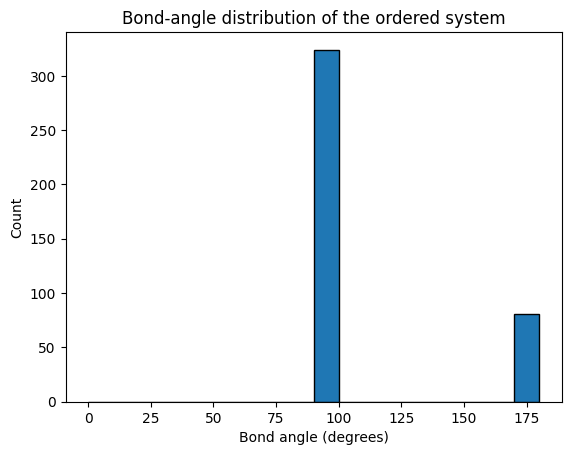

In [26]:
plt.hist(
    all_angles_bf_ordered,
    bins=np.arange(0, 190, 10),
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Count")
plt.title("Bond-angle distribution of the ordered system")

plt.show()

The single-centre result above was first shown as a **frequency plot**, where the vertical axis gives the number of bond angles in each angular interval.

For the following comparisons, the same distribution is instead shown as a **unit-area histogram**. In Python, this is obtained by adding the argument `density=True` to `plt.hist()`. This changes only the vertical scale: the total area of the bars is normalised to one, while the underlying bond-angle data and binning remain unchanged.

Using the unit-area histogram makes it easier to compare bond-angle distributions containing different total numbers of angle samples.

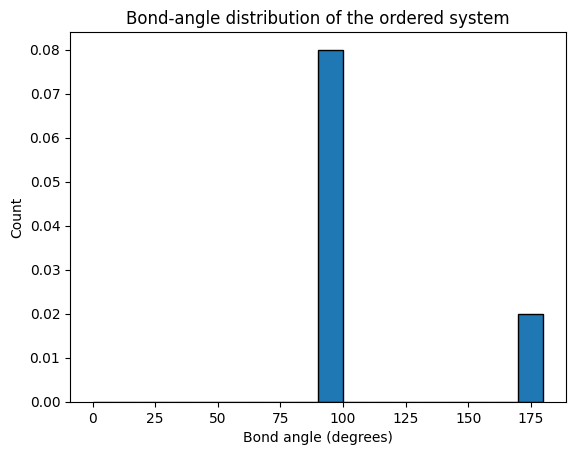

In [30]:
plt.hist(
    all_angles_bf_ordered,
    bins=np.arange(0, 190, 10),
    density=True,
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Count")
plt.title("Bond-angle distribution of the ordered system")

plt.show()

### **Example 2： Cubic randomly packed periodic system**

The same procedure is now applied to a randomly packed periodic system. Unlike the ordered structure, the particle positions are random, while the periodic boundary conditions and minimum-separation constraint are retained. The resulting bond angles are collected from the whole system and the histogram is normalised as a probability density. The previously generated random configuration is now analysed using the same neighbour cutoff and periodic boundary conditions as the ordered system. Bond angles are calculated around every particle and collected to obtain the bond-angle distribution of the whole system. The BAD is shown as an **unit-area histogram** as well.

In [27]:
all_angles_random = []

for center_idx in range(len(random_positions)):

    neighbors = find_neighbors_brute_force(
        positions=random_positions,
        center_idx=center_idx,
        cutoff=cutoff,
        cell=cell
    )

    angles = calculate_bond_angles(neighbors)
    all_angles_random.extend(angles)

all_angles_random = np.array(all_angles_random)

print(f"Total number of bond angles: {len(all_angles_random)}")

Total number of bond angles: 678


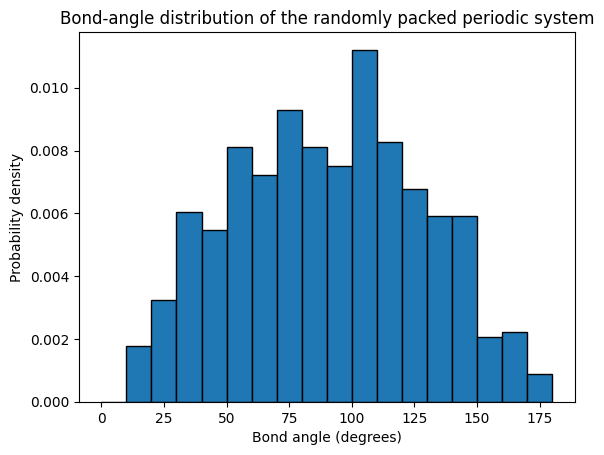

In [28]:
plt.hist(
    all_angles_random,
    bins=np.arange(0, 190, 10),
    density=True,
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Probability density")
plt.title("Bond-angle distribution of the randomly packed periodic system")

plt.show()

> **Note.** For a three-body angle $i-j-k$, the central particle $j$ and the first neighbour $i$ can be regarded as fixed. The end point of the second neighbour vector, corresponding to particle $k$, may lie at different positions around $j$. For a given bond angle $\theta$, the allowed positions of $k$ form a ring on a sphere centred at $j$. A larger ring corresponds to more possible directions for $k$, so a randomly oriented neighbour is more likely to produce angles near $90^\circ$ than near $0^\circ$ or $180^\circ$. This gives a broad angular distribution rather than a uniform one.

The size of this ring varies as $\sin\theta$, giving the characteristic angular dependence $p(\theta)\propto\sin\theta$ for isotropically distributed directions. Compared with the ordered system, the randomly packed periodic system produces a much broader bond-angle distribution. In the ordered structure, neighbour directions are constrained by the regular geometry of the lattice, giving a small number of characteristic bond angles. In the randomly packed system, neighbours can occur over a much wider range of directions, producing a continuous range of bond angles instead of discrete peaks. The broad maximum at intermediate angles is also consistent with the larger number of possible three-dimensional neighbour directions associated with these angles.

### **Example 3: Perturbed ordered system**

The previous examples considered two limiting cases: an ordered cubic system and a randomly packed periodic system. Both systems were constructed using the same simulation cell and the same number of particles, so the particle number density is kept fixed.

To examine how the bond-angle distribution changes as structural order is gradually disturbed, random displacements are now applied to the particles in the ordered system. The resulting perturbed structures retain the same overall particle density, while their local geometry increasingly deviates from the original ordered arrangement.

The bond-angle distribution is then recalculated to examine how the characteristic peaks of the ordered structure change with increasing positional disorder.

#### **Introducing positional disorder**

There are several possible ways to perturb an ordered structure. For example, particle displacements may be sampled from a **Gaussian distribution**, which can arise **naturally for thermal fluctuations in a harmonic approximation**, or from a simpler prescribed random distribution.

Here, a toy-model perturbation is used. Each particle is displaced from its original lattice position by a random direction and a displacement magnitude sampled within a specified range,

$$
\mathbf{r}'_i = \mathbf{r}_i + \Delta\mathbf{r}_i,
$$

with

$$
0 \leq |\Delta\mathbf{r}_i| \leq d_{\max}.
$$

The parameter $d_{\max}$ therefore controls the strength of the positional disorder. This simple model is used to examine how increasing structural perturbation changes the bond-angle distribution, rather than to reproduce the thermal motion of a specific physical material.

> **Physical note.** In a real crystal, thermal disorder is often described as atomic vibrations around equilibrium lattice sites. Under the simplest harmonic approximation,
>
> $$
> V(x)\approx \frac{1}{2}kx^2.
> $$
>
> In the classical canonical ensemble, the positional probability is weighted by the Boltzmann factor,
>
> $$
> P(x)\propto e^{-V(x)/(k_BT)},
> $$
>
> giving
>
> $$
> P(x)\propto
> \exp\left(
> -\frac{kx^2}{2k_BT}
> \right).
> $$
>
> Thus, within this simple harmonic picture, the displacement follows a Gaussian distribution. Real thermal disorder can be more complicated because atomic motions may be correlated, anisotropic, anharmonic, or quantum mechanical. In this toy model, however, a simpler bounded random displacement is used to isolate the effect of increasing positional disorder on the bond-angle distribution.

In [45]:
def perturb_positions(positions, max_displacement, cell, seed=None):
    """
    Apply a random displacement to each particle.

    The displacement direction is random and the displacement magnitude
    is sampled uniformly between 0 and max_displacement.

    Parameters
    ----------
    positions : ndarray, shape (N, 3)
        Original Cartesian particle positions.

    max_displacement : float
        Maximum displacement magnitude in angstroms.

    cell : ndarray, shape (3, 3)
        Simulation cell vectors stored as rows.

    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    perturbed_positions : ndarray, shape (N, 3)
        Perturbed Cartesian particle positions wrapped back into the
        simulation cell.
    """

    rng = np.random.default_rng(seed)

    perturbed_positions = []

    for position in positions:

        # Generate a random direction
        direction = rng.normal(size=3)
        direction /= np.linalg.norm(direction)

        # Random displacement magnitude
        magnitude = rng.uniform(0.0, max_displacement)

        displacement = magnitude * direction
        new_position = position + displacement

        perturbed_positions.append(new_position)

    perturbed_positions = np.array(perturbed_positions)

    # Wrap positions back into the primary simulation cell
    fractional = perturbed_positions @ np.linalg.inv(cell)
    fractional %= 1.0
    perturbed_positions = fractional @ cell

    return perturbed_positions

In [46]:
perturbed_positions_0_5 = perturb_positions(
    positions=ordered_positions,
    max_displacement=0.5,
    cell=cell,
    seed=42
)

In [47]:
print(perturbed_positions_0_5)

[[8.06035884e-02 9.72490400e+00 1.98508923e-01]
 [9.67357713e+00 9.78213557e+00 3.35472199e+00]
 [9.99364605e+00 9.67739116e+00 6.99924222e+00]
 [6.13877051e-03 3.43813118e+00 4.34636112e-02]
 [8.61603110e-02 3.10928602e+00 3.53858727e+00]
 [9.94151621e+00 3.11791175e+00 7.05343471e+00]
 [9.98779517e+00 6.65663293e+00 1.51676868e-02]
 [8.98081990e-02 6.76041079e+00 3.79934331e+00]
 [9.95750456e+00 6.59915642e+00 6.71776806e+00]
 [3.30106477e+00 9.76207771e+00 9.76651676e+00]
 [3.59661640e+00 1.92401637e-01 3.09758971e+00]
 [3.34233290e+00 1.68666756e-02 6.73387688e+00]
 [3.63790583e+00 3.36365049e+00 1.29704017e-01]
 [3.06842447e+00 3.27521756e+00 3.24782025e+00]
 [3.29628567e+00 3.53462588e+00 6.55008326e+00]
 [3.06307943e+00 6.61288711e+00 2.61366931e-02]
 [3.47186095e+00 6.82118915e+00 3.26541116e+00]
 [3.39811235e+00 6.65222278e+00 6.57034962e+00]
 [6.37820719e+00 1.55974082e-01 4.46831808e-02]
 [6.55449958e+00 4.16215905e-02 3.49757023e+00]
 [6.68997383e+00 9.96622493e+00 6.648141

In [48]:
print("Original positions:")
print(np.round(ordered_positions, 3))

Original positions:
[[0.    0.    0.   ]
 [0.    0.    3.333]
 [0.    0.    6.667]
 [0.    3.333 0.   ]
 [0.    3.333 3.333]
 [0.    3.333 6.667]
 [0.    6.667 0.   ]
 [0.    6.667 3.333]
 [0.    6.667 6.667]
 [3.333 0.    0.   ]
 [3.333 0.    3.333]
 [3.333 0.    6.667]
 [3.333 3.333 0.   ]
 [3.333 3.333 3.333]
 [3.333 3.333 6.667]
 [3.333 6.667 0.   ]
 [3.333 6.667 3.333]
 [3.333 6.667 6.667]
 [6.667 0.    0.   ]
 [6.667 0.    3.333]
 [6.667 0.    6.667]
 [6.667 3.333 0.   ]
 [6.667 3.333 3.333]
 [6.667 3.333 6.667]
 [6.667 6.667 0.   ]
 [6.667 6.667 3.333]
 [6.667 6.667 6.667]]


In [49]:
print("\nPerturbed positions:")
print(np.round(perturbed_positions_0_5, 3))


Perturbed positions:
[[8.100e-02 9.725e+00 1.990e-01]
 [9.674e+00 9.782e+00 3.355e+00]
 [9.994e+00 9.677e+00 6.999e+00]
 [6.000e-03 3.438e+00 4.300e-02]
 [8.600e-02 3.109e+00 3.539e+00]
 [9.942e+00 3.118e+00 7.053e+00]
 [9.988e+00 6.657e+00 1.500e-02]
 [9.000e-02 6.760e+00 3.799e+00]
 [9.958e+00 6.599e+00 6.718e+00]
 [3.301e+00 9.762e+00 9.767e+00]
 [3.597e+00 1.920e-01 3.098e+00]
 [3.342e+00 1.700e-02 6.734e+00]
 [3.638e+00 3.364e+00 1.300e-01]
 [3.068e+00 3.275e+00 3.248e+00]
 [3.296e+00 3.535e+00 6.550e+00]
 [3.063e+00 6.613e+00 2.600e-02]
 [3.472e+00 6.821e+00 3.265e+00]
 [3.398e+00 6.652e+00 6.570e+00]
 [6.378e+00 1.560e-01 4.500e-02]
 [6.554e+00 4.200e-02 3.498e+00]
 [6.690e+00 9.966e+00 6.648e+00]
 [6.449e+00 3.422e+00 9.914e+00]
 [6.765e+00 3.424e+00 3.469e+00]
 [6.656e+00 3.331e+00 6.624e+00]
 [6.395e+00 6.462e+00 8.200e-02]
 [6.570e+00 6.999e+00 3.242e+00]
 [6.354e+00 6.598e+00 6.349e+00]]


In [50]:
displacements_0_5 = pbc(
    perturbed_positions_0_5 - ordered_positions,
    cell
)

print("\nDisplacements:")
print(np.round(displacements_0_5, 3))


Displacements:
[[ 0.081 -0.275  0.199]
 [-0.326 -0.218  0.021]
 [-0.006 -0.323  0.333]
 [ 0.006  0.105  0.043]
 [ 0.086 -0.224  0.205]
 [-0.058 -0.215  0.387]
 [-0.012 -0.01   0.015]
 [ 0.09   0.094  0.466]
 [-0.042 -0.068  0.051]
 [-0.032 -0.238 -0.233]
 [ 0.263  0.192 -0.236]
 [ 0.009  0.017  0.067]
 [ 0.305  0.03   0.13 ]
 [-0.265 -0.058 -0.086]
 [-0.037  0.201 -0.117]
 [-0.27  -0.054  0.026]
 [ 0.139  0.155 -0.068]
 [ 0.065 -0.014 -0.096]
 [-0.288  0.156  0.045]
 [-0.112  0.042  0.164]
 [ 0.023 -0.034 -0.019]
 [-0.218  0.089 -0.086]
 [ 0.098  0.091  0.136]
 [-0.011 -0.002 -0.042]
 [-0.272 -0.205  0.082]
 [-0.097  0.333 -0.091]
 [-0.313 -0.069 -0.318]]


#### **Visualising the perturbed structure**

The perturbed structure is first shown using positions wrapped into the primary simulation cell. As with the earlier neighbour visualisation, periodic wrapping can make some particles appear far from their original lattice sites.

A second representation therefore shows each perturbed particle using its minimum-image displacement from the corresponding original position, with thin lines indicating the one-to-one displacements. The two representations are equivalent under periodic boundary conditions.

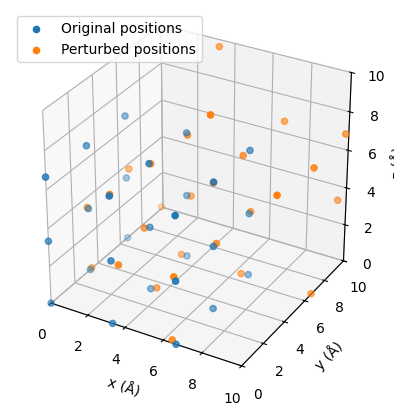

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2],
    label="Original positions"
)

ax.scatter(
    perturbed_positions_0_5[:, 0],
    perturbed_positions_0_5[:, 1],
    perturbed_positions_0_5[:, 2],
    label="Perturbed positions"
)

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.show()

In [52]:
displacements_0_5 = pbc(
    perturbed_positions_0_5 - ordered_positions,
    cell
)

perturbed_display_0_5 = ordered_positions + displacements_0_5

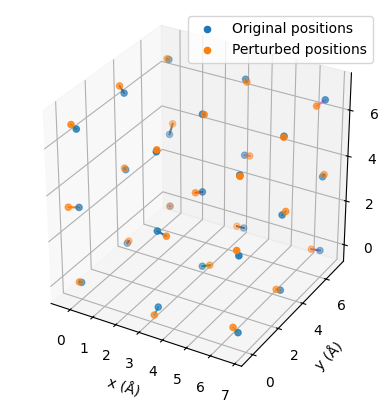

In [53]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ordered_positions[:, 0],
    ordered_positions[:, 1],
    ordered_positions[:, 2],
    label="Original positions"
)

ax.scatter(
    perturbed_display_0_5[:, 0],
    perturbed_display_0_5[:, 1],
    perturbed_display_0_5[:, 2],
    label="Perturbed positions"
)

for original, perturbed in zip(
    ordered_positions,
    perturbed_display_0_5
):
    ax.plot(
        [original[0], perturbed[0]],
        [original[1], perturbed[1]],
        [original[2], perturbed[2]]
    )

ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.show()

#### **Expected change in the bond-angle distribution**

Before calculating the bond-angle distribution, we can first predict how the perturbation should affect the local geometry.

In the ordered cubic structure, neighbour directions are strongly constrained by the regular lattice geometry, producing characteristic bond angles at $90^\circ$ and $180^\circ$. After random displacements are introduced, these geometric constraints are weakened and the neighbour directions are no longer perfectly aligned with the original lattice directions.

The sharp peaks of the ordered system are therefore expected to broaden around their original positions. As the perturbation strength increases, the distribution should gradually move towards the broader bond-angle distribution observed for the randomly packed periodic system.

In [54]:
all_angles_perturbed_0_5 = []

for center_idx in range(len(perturbed_positions_0_5)):

    neighbors = find_neighbors_brute_force(
        positions=perturbed_positions_0_5,
        center_idx=center_idx,
        cutoff=cutoff,
        cell=cell
    )

    angles = calculate_bond_angles(neighbors)
    all_angles_perturbed_0_5.extend(angles)

all_angles_perturbed_0_5 = np.array(all_angles_perturbed_0_5)

print(f"Total number of bond angles: {len(all_angles_perturbed_0_5)}")

Total number of bond angles: 405


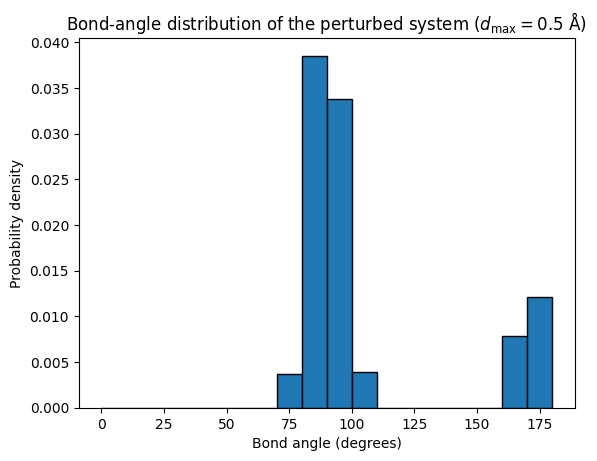

In [56]:
plt.hist(
    all_angles_perturbed_0_5,
    bins=np.arange(0, 190, 10),
    density=True,
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Probability density")
plt.title(r"Bond-angle distribution of the perturbed system ($d_{\max}=0.5$ Å)")

plt.show()

The calculated distribution follows the expected trend. The characteristic peaks near $90^\circ$ and $180^\circ$ are retained but broadened, showing that the original ordered geometry is still partially preserved while positional disorder weakens the strict lattice constraints.

The perturbed structure therefore lies between the perfectly ordered system and the randomly packed periodic system.

### **Example 4: Non-periodic ideal-gas reference**

The randomly packed system considered above is still periodic: one random configuration is defined within the simulation cell and repeated through periodic boundary conditions. As a final reference case, an uncorrelated non-periodic system is considered. Particle positions are sampled independently within the finite simulation box, without a minimum-separation constraint and without periodic boundary conditions.

This provides a simple structure-free reference for comparison with the ordered, perturbed, and periodically packed systems.

In [58]:
def generate_ideal_gas_positions(n_particles, cell, seed=None):
    """
    Generate independent random particle positions in a finite simulation box.

    No minimum-separation constraint or periodic boundary condition is applied.
    """
    rng = np.random.default_rng(seed)

    fractional_positions = rng.random((n_particles, 3))
    positions = fractional_positions @ cell

    return positions

In [59]:
ideal_gas_positions = generate_ideal_gas_positions(
    n_particles=N,
    cell=cell,
    seed=42
)

In [60]:
def find_neighbors_brute_force_nonperiodic(
    positions,
    center_idx,
    cutoff
):
    neighbors = []
    center = positions[center_idx]

    for idx, position in enumerate(positions):
        if idx == center_idx:
            continue

        displacement = position - center
        distance = np.linalg.norm(displacement)

        if distance < cutoff:
            neighbors.append((idx, displacement))

    return neighbors

In [61]:
all_angles_ideal_gas = []

for center_idx in range(len(ideal_gas_positions)):

    neighbors = find_neighbors_brute_force_nonperiodic(
        positions=ideal_gas_positions,
        center_idx=center_idx,
        cutoff=cutoff
    )

    angles = calculate_bond_angles(neighbors)
    all_angles_ideal_gas.extend(angles)

all_angles_ideal_gas = np.array(all_angles_ideal_gas)

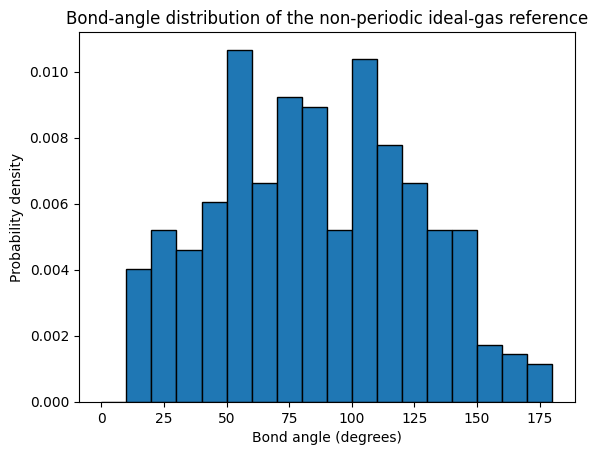

In [62]:
plt.hist(
    all_angles_ideal_gas,
    bins=np.arange(0, 190, 10),
    density=True,
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Probability density")
plt.title("Bond-angle distribution of the non-periodic ideal-gas reference")

plt.show()

The diagram above shows the bond angle distributions of a single random configuration of idea gas. Because a single random configuration contains substantial statistical fluctuations, the ideal-gas reference is averaged over multiple independently generated configurations. This reduces sampling noise and gives a more representative bond-angle distribution. What we need is emsemble averaging, i.e. avaerage BAD over many independent random configurations.

> **Design note.** The periodically packed random system and the ideal-gas reference represent two different treatments of randomness.  
>
> In the periodic system, one random configuration is defined inside the simulation cell and repeated through periodic boundary conditions. Conceptually, a $3\times3\times3$ set of periodic images would therefore contain identical copies of the same configuration.
>
> For the ideal-gas reference, independent random configurations are generated instead. These configurations are not periodic replicas of one another and are analysed without periodic boundary conditions. Averaging over many such independent configurations provides the ensemble-averaged bond-angle distribution.

In [63]:
all_angles_ideal_gas_ensemble = []

n_configurations = 100

for seed in range(n_configurations):

    positions = generate_ideal_gas_positions(
        n_particles=N,
        cell=cell,
        seed=seed
    )

    for center_idx in range(len(positions)):

        neighbors = find_neighbors_brute_force_nonperiodic(
            positions=positions,
            center_idx=center_idx,
            cutoff=cutoff
        )

        angles = calculate_bond_angles(neighbors)
        all_angles_ideal_gas_ensemble.extend(angles)

all_angles_ideal_gas_ensemble = np.array(all_angles_ideal_gas_ensemble)

print(f"Number of configurations: {n_configurations}")
print(f"Total number of bond angles: {len(all_angles_ideal_gas_ensemble)}")

Number of configurations: 100
Total number of bond angles: 26978


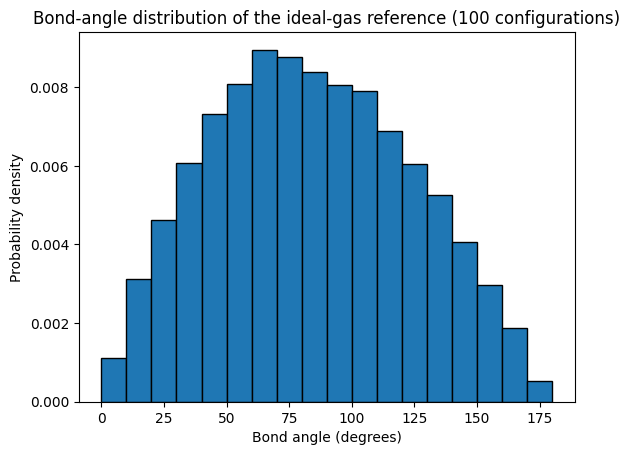

In [64]:
plt.hist(
    all_angles_ideal_gas_ensemble,
    bins=np.arange(0, 190, 10),
    density=True,
    edgecolor="black"
)

plt.xlabel("Bond angle (degrees)")
plt.ylabel("Probability density")
plt.title(
    f"Bond-angle distribution of the ideal-gas reference "
    f"({n_configurations} configurations)"
)

plt.show()

Averaging over 100 independent configurations substantially reduces the statistical fluctuations observed for a single configuration, revealing a smooth, broad bond-angle distribution. The distribution should not be interpreted as Gaussian; its shape arises from the three-dimensional angular geometry together with the finite, non-periodic simulation box and the neighbour cutoff.